
# Install dependencies


In [1]:
!pip -q install pandas numpy scikit-learn matplotlib tensorflow keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00


#Imports & Mount Google Drive

In [102]:
import os, zipfile, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Directory to save checkpoints
CHECKPOINT_DIR = "/content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
start_epoch = 1  # reset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Download NAB Dataset

In [103]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
nab_zip_path = os.path.join(DATA_DIR, "nab.zip")
nab_url = "https://github.com/numenta/NAB/archive/refs/heads/master.zip"

if not os.path.exists(nab_zip_path):
    print("Downloading NAB dataset...")
    urllib.request.urlretrieve(nab_url, nab_zip_path)

nab_root = os.path.join(DATA_DIR, "NAB-master")
if not os.path.exists(nab_root):
    print("Unzipping...")
    with zipfile.ZipFile(nab_zip_path, 'r') as z:
        z.extractall(DATA_DIR)

csv_path = os.path.join(nab_root, "data", "realTraffic", "speed_6005.csv")
json_label_path = os.path.join(nab_root, "labels", "combined_labels.json")

#Load & preprocess CSV

In [104]:
df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["value"] = df["value"].interpolate(method="time", limit_direction="both").fillna(method="ffill").fillna(method="bfill")

scaler = StandardScaler()
df["value_scaled"] = scaler.fit_transform(df[["value"]])

/tmp/ipykernel_495/2120350521.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["value"] = df["value"].interpolate(method="time", limit_direction="both").fillna(method="ffill").fillna(method="bfill")


# Load Labels FIRST

In [105]:
# Load combined_labels.json properly
with open(json_label_path, "r") as f:
    label_json = json.load(f)

print("Keys inside label file:")
print(list(label_json.keys())[:10])

Keys inside label file:
['artificialNoAnomaly/art_daily_no_noise.csv', 'artificialNoAnomaly/art_daily_perfect_square_wave.csv', 'artificialNoAnomaly/art_daily_small_noise.csv', 'artificialNoAnomaly/art_flatline.csv', 'artificialNoAnomaly/art_noisy.csv', 'artificialWithAnomaly/art_daily_flatmiddle.csv', 'artificialWithAnomaly/art_daily_jumpsdown.csv', 'artificialWithAnomaly/art_daily_jumpsup.csv', 'artificialWithAnomaly/art_daily_nojump.csv', 'artificialWithAnomaly/art_increase_spike_density.csv']


In [106]:
print("Entries for this file:")
print(label_json.get("realTraffic/speed_6005.csv"))

Entries for this file:
['2015-09-17 07:00:00']


#Load NAB anomaly labels

In [107]:
# Load labels first
with open(json_label_path, "r") as f:
    label_json = json.load(f)

anomaly_entries = label_json.get("realTraffic/speed_6005.csv", [])

# Create anomaly column
df["is_anomaly"] = 0
for entry in anomaly_entries:
    ts = pd.to_datetime(entry)
    idx = (df["timestamp"] - ts).abs().idxmin()
    df.loc[idx, "is_anomaly"] = 1

print("Number of anomaly timestamps in JSON:", len(anomaly_entries))
print("Anomaly indices in df:", df.index[df['is_anomaly']==1].tolist())
print("Total anomaly points in dataframe:", df["is_anomaly"].sum())

Number of anomaly timestamps in JSON: 1
Anomaly indices in df: [2386]
Total anomaly points in dataframe: 1


# Sliding windows

In [108]:
WINDOW_SIZE = 100  # try longer sequences
STEP = 5           # reduce overlap to prevent overfitting
series = df["value_scaled"].values.astype(np.float32)

def make_windows(series, window_size=WINDOW_SIZE, step=STEP):
    X = []
    for start in range(0, len(series)-window_size+1, step):
        X.append(series[start:start+window_size])
    return np.array(X)

X = make_windows(series, WINDOW_SIZE, STEP)

# Window-level labels

In [109]:
def make_window_labels(df, window_size=WINDOW_SIZE, step=STEP):

    y = []
    anomaly_series = df["is_anomaly"].values

    for start in range(0, len(anomaly_series)-window_size+1, step):
        window = anomaly_series[start:start+window_size]
        y.append(int(window.max() == 1))

    return np.array(y)

# Create y

In [110]:
Y = make_window_labels(df, WINDOW_SIZE, STEP)

print("Total window anomalies:", Y.sum())

Total window anomalies: 20


# Split Train / Val / Test

In [111]:
n = len(X)
train_end = int(n*0.7)
val_end   = int(n*0.85)
X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

# Build Masked Autoencoder

In [112]:
TIMESTEPS = X_train.shape[1]

# --- Data Augmentation Function ---
def augment_windows(x, noise_std=0.005, scale_range=(0.95, 1.05)):
    """
    Adds Gaussian noise and random scaling to normal windows.
    x: [batch, timesteps, 1]
    """
    # Gaussian noise
    x_noisy = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=noise_std)
    # Random scaling per window
    scales = tf.random.uniform([tf.shape(x)[0], 1, 1], scale_range[0], scale_range[1])
    return x_noisy * scales

# --- Masking Function ---
def apply_random_mask(x, mask_ratio=0.2):
    b = tf.shape(x)[0]
    t = tf.shape(x)[1]
    mask = tf.cast(tf.random.uniform((b, t), 0, 1) < mask_ratio, tf.float32)
    x_masked = x * tf.expand_dims(1 - mask, -1)
    return x_masked, tf.expand_dims(mask, -1)

# --- Autoencoder with stable residuals ---
inputs = keras.Input(shape=(TIMESTEPS, 1))

# Encoder
x = layers.Conv1D(64, 5, padding="same", activation="relu", kernel_initializer="he_normal")(inputs)
x = layers.Conv1D(128, 5, padding="same", activation="relu", kernel_initializer="he_normal")(x)
x = layers.Dropout(0.1)(x)

# First downsample + residual
res = x
x = layers.Conv1D(256, 3, padding="same", activation="relu", strides=2, kernel_initializer="he_normal")(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
# Project residual to match downsample shape
res_down = layers.Conv1D(256, 1, strides=2, padding="same")(res)
x = layers.Add()([x, res_down])
x = layers.Dropout(0.1)(x)

# Second downsample + residual
res = x
x = layers.Conv1D(256, 3, padding="same", activation="relu", strides=2, kernel_initializer="he_normal")(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
res_down = layers.Conv1D(256, 1, strides=2, padding="same")(res)
x = layers.Add()([x, res_down])

# Decoder
# First upsample
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)

# Second upsample
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(128, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)

# Final reconstruction
x = layers.Conv1D(64, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
outputs = layers.Conv1D(1, 3, padding="same")(x)

# Model
autoencoder = keras.Model(inputs, outputs)
optimizer = keras.optimizers.Adam(1e-4)  # lower LR for stability

# --- Masked Loss ---
@tf.function
def masked_loss(x, recon, mask):
    diff = (x - recon) * mask
    return tf.reduce_sum(tf.square(diff)) / (tf.reduce_sum(mask) + 1e-8)

# --- Training / Validation Steps ---
@tf.function
def train_step(x):
    x_aug = augment_windows(x)
    x_masked, mask = apply_random_mask(x_aug, 0.25)  # lighter masking for stable training
    with tf.GradientTape() as tape:
        recon = autoencoder(x_masked, training=True)
        loss = masked_loss(x, recon, mask)
    grads = tape.gradient(loss, autoencoder.trainable_variables)
    optimizer.apply_gradients(zip(grads, autoencoder.trainable_variables))
    return loss

@tf.function
def val_step(x):
    x_aug = augment_windows(x)
    x_masked, mask = apply_random_mask(x_aug, 0.25)
    recon = autoencoder(x_masked, training=False)
    return masked_loss(x, recon, mask)

# Prepare datasets for training

In [113]:
BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices(X_train[...,None]).shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices(X_val[...,None]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Train Masked Autoencoder with checkpoints

In [114]:
EPOCHS = 40
best_val = 1e9
patience = 3
wait = 0
start_epoch = 1

# Find latest checkpoint
latest_epoch = 0
latest_ae_ckpt = None

for f in os.listdir(CHECKPOINT_DIR):
    if "masked_autoencoder_epoch" in f:
        epoch_num = int(f.split("epoch")[1].split(".")[0])
        if epoch_num > latest_epoch:
            latest_epoch = epoch_num
            latest_ae_ckpt = os.path.join(CHECKPOINT_DIR, f)

if latest_ae_ckpt:
    print(f"Resuming Autoencoder from: {latest_ae_ckpt}")
    autoencoder = keras.models.load_model(latest_ae_ckpt, compile=False)
    optimizer = keras.optimizers.Adam(3e-4)
    start_epoch = latest_epoch + 1

# Training loop
for epoch in range(start_epoch, EPOCHS+1):

    tr = [train_step(xb).numpy() for xb in train_ds]
    va = [val_step(xb).numpy() for xb in val_ds]

    tr_loss = float(np.mean(tr))
    va_loss = float(np.mean(va))

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}")

    # Save checkpoint
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"masked_autoencoder_epoch{epoch:02d}.keras")
    autoencoder.save(ckpt_path)

    if va_loss < best_val:
        best_val = va_loss
        wait = 0
        autoencoder.save(os.path.join(CHECKPOINT_DIR, "masked_autoencoder_best.keras"))
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

Epoch 01 | train_loss=2.007060 | val_loss=1.408633
Epoch 02 | train_loss=1.314222 | val_loss=1.144953
Epoch 03 | train_loss=1.127582 | val_loss=1.065432
Epoch 04 | train_loss=1.026044 | val_loss=1.094261
Epoch 05 | train_loss=0.963603 | val_loss=0.906174
Epoch 06 | train_loss=0.942643 | val_loss=1.010133
Epoch 07 | train_loss=0.919297 | val_loss=0.948747
Epoch 08 | train_loss=0.888213 | val_loss=0.866563
Epoch 09 | train_loss=0.892436 | val_loss=0.966878
Epoch 10 | train_loss=0.893262 | val_loss=0.935131
Epoch 11 | train_loss=0.911470 | val_loss=0.893104
Early stopping triggered.


# Load Best Autoencoder & Prepare Encoder

In [115]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import os

# Correct decorator for TF 2.12+
@keras.utils.register_keras_serializable()
def crop_to_timesteps(x):
    TIMESTEPS = 50  # match your training TIMESTEPS
    return x[:, :TIMESTEPS, :]

# Load the saved model
autoencoder = keras.models.load_model(
    os.path.join(CHECKPOINT_DIR, "masked_autoencoder_best.keras"),
    compile=False
)

# Inspect all layers safely
for i, layer in enumerate(autoencoder.layers):
    try:
        shape = layer.output.shape
    except AttributeError:
        shape = "no output shape"
    print(i, layer.name, shape)

# Create encoder from latent layer (adjust the index if needed)
encoder = keras.Model(autoencoder.input, autoencoder.layers[-6].output)
print("Encoder ready. Output shape:", encoder.output.shape)

0 input_layer_15 (None, 100, 1)
1 conv1d_83 (None, 100, 64)
2 conv1d_84 (None, 100, 128)
3 dropout_17 (None, 100, 128)
4 conv1d_85 (None, 50, 256)
5 conv1d_86 (None, 50, 256)
6 conv1d_87 (None, 50, 256)
7 add_9 (None, 50, 256)
8 dropout_18 (None, 50, 256)
9 conv1d_88 (None, 25, 256)
10 conv1d_89 (None, 25, 256)
11 conv1d_90 (None, 25, 256)
12 add_10 (None, 25, 256)
13 up_sampling1d_20 (None, 50, 256)
14 conv1d_91 (None, 50, 256)
15 up_sampling1d_21 (None, 100, 256)
16 conv1d_92 (None, 100, 128)
17 conv1d_93 (None, 100, 64)
18 conv1d_94 (None, 100, 1)
Encoder ready. Output shape: (None, 50, 256)


# Prepare Support & Query Embeddings
# Remove Precomputed Embeddings

In [116]:
# ==========================================
# DO NOT PRECOMPUTE EMBEDDINGS
# We train Siamese end-to-end
# ==========================================

print("Preparing Siamese training data (raw windows)...")

normal_idx = np.where(Y_train == 0)[0]
anomaly_idx = np.where(Y_train == 1)[0]

print("Normal samples:", len(normal_idx))
print("Anomaly samples:", len(anomaly_idx))

Preparing Siamese training data (raw windows)...
Normal samples: 336
Anomaly samples: 0


In [117]:
print("Total windows:", len(X))
print("Total anomaly windows:", Y.sum())
print("Train window anomaly count:", Y_train.sum())
print("Val window anomaly count:", Y_val.sum())
print("Test window anomaly count:", Y_test.sum())

Total windows: 481
Total anomaly windows: 20
Train window anomaly count: 0
Val window anomaly count: 0
Test window anomaly count: 20


# Proper Triplet Generator (RAW INPUT, Not Embeddings)

In [118]:
# Make sure series windows have correct shape
X_train_windows = X_train.astype(np.float32)  # shape: (num_windows, 60)
Y_train_labels = Y_train

# Proper Hybrid Triplet Generator
def generate_hybrid_triplets(X, Y, num_triplets=6000):
    """
    Generates triplets for hybrid Siamese:
    - Anchors + Positives: normal windows
    - Negatives: pseudo-anomalies (highest AE reconstruction error)
    """
    normal_idx = np.where(Y==0)[0]
    if len(normal_idx) < 2:
        raise ValueError("Not enough normal windows to generate triplets")

    # Use reconstruction error to select pseudo-negative
    recon_X = autoencoder.predict(X[...,None], verbose=0)
    errors = np.mean((X[...,None] - recon_X)**2, axis=(1,2))

    top_idx = errors.argsort()[-int(0.10*len(errors)):]
    rand_idx = np.random.choice(normal_idx, int(0.05*len(normal_idx)), replace=False)
    pseudo_neg_idx = np.concatenate([top_idx, rand_idx])

    anchors, positives, negatives = [], [], []

    for _ in range(num_triplets):
        a, p = np.random.choice(normal_idx, 2, replace=False)
        n = np.random.choice(pseudo_neg_idx)
        anchors.append(X[a])
        positives.append(X[p])
        negatives.append(X[n])

    # Add channel dimension for Conv1D
    return np.array(anchors)[..., None], np.array(positives)[..., None], np.array(negatives)[..., None]

# Generate triplets
anchor, positive, negative = generate_hybrid_triplets(
    X_train_windows, Y_train_labels, num_triplets=12000
)

print("Anchor shape:", anchor.shape)    # should be (12000, 60, 1)
print("Positive shape:", positive.shape)
print("Negative shape:", negative.shape)

Anchor shape: (12000, 100, 1)
Positive shape: (12000, 100, 1)
Negative shape: (12000, 100, 1)


# REAL Hybrid Siamese (Uses Encoder Inside)

In [119]:
from tensorflow.keras.layers import Lambda

In [120]:
# ==========================================
# HYBRID SIAMESE (Encoder Shared)
# ==========================================

# Use pretrained encoder
shared_encoder = encoder

# Freeze early layers for stability
for layer in shared_encoder.layers[:3]:
    layer.trainable = False

# Inputs
input_anchor = keras.Input(shape=(TIMESTEPS,1))
input_pos    = keras.Input(shape=(TIMESTEPS,1))
input_neg    = keras.Input(shape=(TIMESTEPS,1))

# Pass through encoder
emb_anchor = shared_encoder(input_anchor)
emb_pos    = shared_encoder(input_pos)
emb_neg    = shared_encoder(input_neg)

# Pooling
emb_anchor = layers.GlobalAveragePooling1D()(emb_anchor)
emb_pos    = layers.GlobalAveragePooling1D()(emb_pos)
emb_neg    = layers.GlobalAveragePooling1D()(emb_neg)

# Normalize embeddings (use Lambda to handle KerasTensor)
emb_anchor = Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(emb_anchor)
emb_pos    = Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(emb_pos)
emb_neg    = Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(emb_neg)

# Concatenate
output = layers.Concatenate(axis=1)([emb_anchor, emb_pos, emb_neg])

siamese_model = keras.Model(
    inputs=[input_anchor, input_pos, input_neg],
    outputs=output
)

print("Hybrid Siamese built.")

Hybrid Siamese built.


# Correct Triplet Loss

In [121]:
def triplet_loss(margin=0.5):

    def loss(y_true, y_pred):

        dim = y_pred.shape[1] // 3

        anchor   = y_pred[:, 0:dim]
        positive = y_pred[:, dim:2*dim]
        negative = y_pred[:, 2*dim:3*dim]

        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

        return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))

    return loss

siamese_model.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss=triplet_loss(margin=0.6)
)

siamese_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_12       │ (None, 50, 256)   │    829,440 │ input_layer_16[0… │
│ (Functional)        │                   │            │ input_layer_17[0… │
│                     │                   │            │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_12[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_12[1]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_12[2]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 768)       │          0 │ lambda_7[0][0],   │
│ (Concatenate)       │                   │            │ lambda_8[0][0],   │
│                     │                   │            │ lambda_9[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 829,440 (3.16 MB)

 Trainable params: 787,968 (3.01 MB)

 Non-trainable params: 41,472 (162.00 KB)

# Train Siamese Properly

In [122]:
triplet_ckpt_path = os.path.join(CHECKPOINT_DIR, "siamese_best.keras")

triplet_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=triplet_ckpt_path,
    save_best_only=True,
    monitor='loss',
    mode='min',
    verbose=1
)

siamese_model.fit(
    [anchor, positive, negative],
    np.zeros(len(anchor)),
    batch_size=64,
    epochs=20,
    callbacks=[triplet_checkpoint_cb],
    verbose=1
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5518
Epoch 1: loss improved from inf to 0.48183, saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 0.5514
Epoch 2/20
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2965
Epoch 2: loss improved from 0.48183 to 0.27035, saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2961
Epoch 3/20
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2235
Epoch 3: loss improved from 0.27035 to 0.22378, saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2235
Epoch 4/20
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2024
Epoch 4: loss improved from 0.22378 to 0.19687, saving model to /content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest/siamese_best.ke

# FEW-SHOT PROTOTYPE ANOMALY SCORING (REAL HYBRID)

In [123]:
# ==========================================
# Compute embeddings AFTER Siamese training
# ==========================================

def get_embeddings(X):
    emb = shared_encoder(X[...,None])
    emb = layers.GlobalAveragePooling1D()(emb)
    emb = tf.nn.l2_normalize(emb, axis=1)
    return emb

train_emb = get_embeddings(X_train)
val_emb   = get_embeddings(X_val)
test_emb  = get_embeddings(X_test)

# Prototype of normal class
normal_proto = tf.reduce_mean(
    train_emb[Y_train == 0],
    axis=0
)

# Distance from prototype
val_scores  = tf.norm(val_emb - normal_proto, axis=1).numpy()
test_scores = tf.norm(test_emb - normal_proto, axis=1).numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(336, 100, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(72, 100, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(73, 100, 1))
  warnings.warn(msg)


# Correct Threshold (Only Normal Validation)

In [124]:
from sklearn.metrics import f1_score

best_f1 = 0
best_thresh = 0
for t in np.linspace(np.min(val_scores), np.max(val_scores), 100):
    preds = (val_scores > t).astype(int)
    f1 = f1_score(Y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

threshold = best_thresh

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Evaluate

In [127]:
# ==========================================
# SAFE EVALUATION & METRICS
# ==========================================

# Ensure embeddings for test set
def get_embeddings(X):
    """Compute normalized embeddings for each window."""
    emb = shared_encoder(X[..., None])                  # (num_windows, latent_dim, channels)
    emb = layers.GlobalAveragePooling1D()(emb)         # (num_windows, latent_dim)
    emb = tf.nn.l2_normalize(emb, axis=1)
    return emb

# Compute embeddings
train_emb = get_embeddings(X_train)
val_emb   = get_embeddings(X_val)
test_emb  = get_embeddings(X_test)

# Prototype for normal class (mean of normal training embeddings)
normal_proto = tf.reduce_mean(train_emb[Y_train==0], axis=0)

# Compute distance of each embedding to normal prototype
train_scores = tf.norm(train_emb - normal_proto, axis=1).numpy()
val_scores   = tf.norm(val_emb - normal_proto, axis=1).numpy()
test_scores  = tf.norm(test_emb - normal_proto, axis=1).numpy()

# Threshold based on 90th percentile of normal validation windows
threshold = np.percentile(val_scores[Y_val==0], 90)
print("Threshold (90th percentile of normal val):", threshold)

# Predict anomalies
predictions = (test_scores > threshold).astype(int)

# Make sure shapes match
assert len(predictions) == len(Y_test), f"Shape mismatch: {len(predictions)} vs {len(Y_test)}"

# Compute metrics
precision = precision_score(Y_test, predictions)
recall    = recall_score(Y_test, predictions)
f1        = f1_score(Y_test, predictions)
conf_matrix = confusion_matrix(Y_test, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(336, 100, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(72, 100, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_15']
Received: inputs=Tensor(shape=(73, 100, 1))
  warnings.warn(msg)


Threshold (90th percentile of normal val): 0.59531885
Precision: 0.6818
Recall:    0.7500
F1 Score:  0.7143
Confusion Matrix:
 [[46  7]
 [ 5 15]]


# Plot

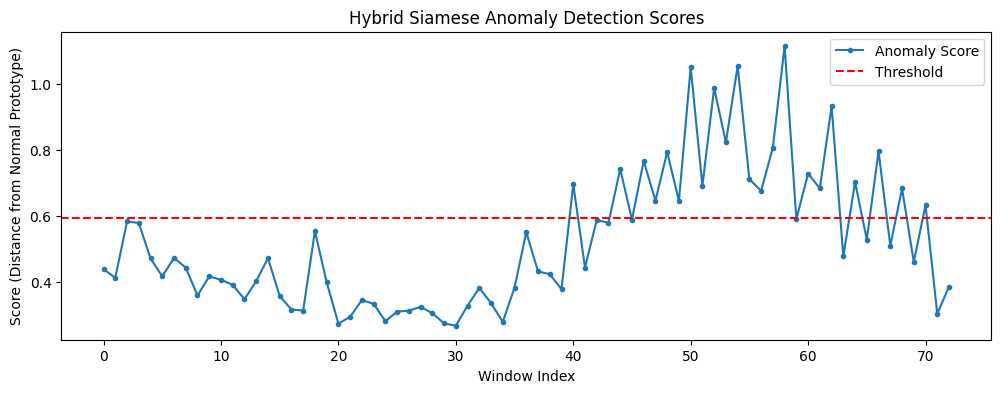

In [128]:
# ==========================================
# Plot anomaly scores
# ==========================================
plt.figure(figsize=(12,4))
plt.plot(test_scores, label="Anomaly Score", marker='o', markersize=3)
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.title("Hybrid Siamese Anomaly Detection Scores")
plt.xlabel("Window Index")
plt.ylabel("Score (Distance from Normal Prototype)")
plt.legend()
plt.show()